# สามารถ จำรัส, ID 6810038288, วิชา MN631.ipynb

In [38]:
# ==========================================
# Create Data Dictionary for Mock Re-triage Dataset
# ==========================================

import pandas as pd

# โหลดข้อมูลจาก GitHub
url = "https://raw.githubusercontent.com/Samart-Jamrat/MN631_project/main/mock_retriage_temporal_2000.csv"
df = pd.read_csv(url)

# สร้าง data dictionary
data_dict = [
    {
        "Column": "patient_id",
        "Data Type": "Integer",
        "Description": "รหัสประจำตัวผู้ป่วยจำลอง ใช้ระบุผู้ป่วยแต่ละราย",
        "Example": "1"
    },
    {
        "Column": "age",
        "Data Type": "Integer",
        "Description": "อายุของผู้ป่วย หน่วยเป็นปี",
        "Example": "69"
    },
    {
        "Column": "sex",
        "Data Type": "Categorical",
        "Description": "เพศของผู้ป่วย",
        "Example": "male / female"
    },
    {
        "Column": "chief_complaint",
        "Data Type": "Categorical",
        "Description": "อาการสำคัญหรือเหตุผลหลักที่ผู้ป่วยมารับบริการ",
        "Example": "fever, dyspnea, chest_pain"
    },
    {
        "Column": "initial_triage_level",
        "Data Type": "Integer / Ordinal",
        "Description": "ระดับความเร่งด่วนจากการคัดกรองครั้งแรก โดยค่าที่น้อยกว่าหมายถึงเร่งด่วนมากกว่า",
        "Example": "2, 3, 4, 5"
    },
    {
        "Column": "wait_minutes",
        "Data Type": "Integer",
        "Description": "ระยะเวลาที่ผู้ป่วยรอ หน่วยเป็นนาที",
        "Example": "99"
    },
    {
        "Column": "repeated_measure_count",
        "Data Type": "Integer",
        "Description": "จำนวนครั้งที่มีการวัดสัญญาณชีพซ้ำระหว่างรอ",
        "Example": "3"
    },
    {
        "Column": "trend_type",
        "Data Type": "Categorical",
        "Description": "ลักษณะแนวโน้มของสัญญาณชีพระหว่างรอ",
        "Example": "stable, improving, worsening, fluctuating"
    },
]

# เพิ่ม vital signs แบบ time steps t1-t5
vital_descriptions = {
    "systolic_bp": "ค่าความดันโลหิตตัวบน",
    "diastolic_bp": "ค่าความดันโลหิตตัวล่าง",
    "pulse": "อัตราการเต้นของหัวใจ",
    "rr": "อัตราการหายใจ",
    "spo2": "ค่าความอิ่มตัวของออกซิเจนในเลือด",
    "temp": "อุณหภูมิร่างกาย"
}

vital_units = {
    "systolic_bp": "mmHg",
    "diastolic_bp": "mmHg",
    "pulse": "beats/min",
    "rr": "breaths/min",
    "spo2": "%",
    "temp": "°C"
}

for vital, desc in vital_descriptions.items():
    for t in range(1, 6):
        data_dict.append({
            "Column": f"{vital}_t{t}",
            "Data Type": "Numeric",
            "Description": f"{desc} ณ time step ที่ {t}",
            "Example": f"{vital_units[vital]}"
        })

# เพิ่ม derived features
derived_features = [
    {
        "Column": "delta_pulse",
        "Data Type": "Numeric",
        "Description": "การเปลี่ยนแปลงของ pulse ระหว่าง time step ที่ 5 เทียบกับ time step ที่ 1",
        "Example": "pulse_t5 - pulse_t1"
    },
    {
        "Column": "delta_sbp",
        "Data Type": "Numeric",
        "Description": "การเปลี่ยนแปลงของ systolic blood pressure ระหว่าง time step ที่ 5 เทียบกับ time step ที่ 1",
        "Example": "systolic_bp_t5 - systolic_bp_t1"
    },
    {
        "Column": "delta_spo2",
        "Data Type": "Numeric",
        "Description": "การเปลี่ยนแปลงของ SpO2 ระหว่าง time step ที่ 5 เทียบกับ time step ที่ 1",
        "Example": "spo2_t5 - spo2_t1"
    },
    {
        "Column": "delta_temp",
        "Data Type": "Numeric",
        "Description": "การเปลี่ยนแปลงของอุณหภูมิร่างกายระหว่าง time step ที่ 5 เทียบกับ time step ที่ 1",
        "Example": "temp_t5 - temp_t1"
    },
    {
        "Column": "mean_pulse",
        "Data Type": "Numeric",
        "Description": "ค่าเฉลี่ยของ pulse จาก time step ที่ 1 ถึง 5",
        "Example": "mean(pulse_t1 to pulse_t5)"
    },
    {
        "Column": "mean_sbp",
        "Data Type": "Numeric",
        "Description": "ค่าเฉลี่ยของ systolic blood pressure จาก time step ที่ 1 ถึง 5",
        "Example": "mean(systolic_bp_t1 to systolic_bp_t5)"
    },
    {
        "Column": "mean_spo2",
        "Data Type": "Numeric",
        "Description": "ค่าเฉลี่ยของ SpO2 จาก time step ที่ 1 ถึง 5",
        "Example": "mean(spo2_t1 to spo2_t5)"
    },
    {
        "Column": "mean_temp",
        "Data Type": "Numeric",
        "Description": "ค่าเฉลี่ยของอุณหภูมิร่างกายจาก time step ที่ 1 ถึง 5",
        "Example": "mean(temp_t1 to temp_t5)"
    },
    {
        "Column": "label",
        "Data Type": "Categorical / Target",
        "Description": "ผลลัพธ์หรือคำแนะนำที่ต้องการให้โมเดลทำนาย",
        "Example": "continue_waiting, observe_closely, re_triage_now"
    }
]

data_dict.extend(derived_features)

# แปลงเป็น DataFrame
data_dict_df = pd.DataFrame(data_dict)

# แสดง Data Dictionary
data_dict_df

,Column,Data Type,Description,Example
0,patient_id,Integer,รหัสประจำตัวผู้ป่วยจำลอง ใช้ระบุผู้ป่วยแต่ละราย,1
1,age,Integer,อายุของผู้ป่วย หน่วยเป็นปี,69
2,sex,Categorical,เพศของผู้ป่วย,male / female
3,chief_complaint,Categorical,อาการสำคัญหรือเหตุผลหลักที่ผู้ป่วยมารับบริการ,"fever, dyspnea, chest_pain"
4,initial_triage_level,Integer / Ordinal,ระดับความเร่งด่วนจากการคัดกรองครั้งแรก โดยค่าท...,"2, 3, 4, 5"
5,wait_minutes,Integer,ระยะเวลาที่ผู้ป่วยรอ หน่วยเป็นนาที,99
6,repeated_measure_count,Integer,จำนวนครั้งที่มีการวัดสัญญาณชีพซ้ำระหว่างรอ,3
7,trend_type,Categorical,ลักษณะแนวโน้มของสัญญาณชีพระหว่างรอ,"stable, improving, worsening, fluctuating"
8,systolic_bp_t1,Numeric,ค่าความดันโลหิตตัวบน ณ time step ที่ 1,mmHg
9,systolic_bp_t2,Numeric,ค่าความดันโลหิตตัวบน ณ time step ที่ 2,mmHg


In [1]:
# ==========================================
# Step 1: Load mock temporal ER dataset
# ==========================================

import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/Samart-Jamrat/MN631_project/main/mock_retriage_temporal_2000.csv"

df = pd.read_csv(url)

print("Dataset shape:", df.shape)
display(df.head())
print(df.columns.tolist())

Dataset shape: (2000, 47)


,patient_id,age,sex,chief_complaint,initial_triage_level,wait_minutes,repeated_measure_count,trend_type,systolic_bp_t1,diastolic_bp_t1,...,temp_t5,delta_pulse,delta_sbp,delta_spo2,delta_temp,mean_pulse,mean_sbp,mean_spo2,mean_temp,label
0,1,69,male,chest_pain,2,146,2,worsening,120.0,78.0,...,37.2,14.0,-7.0,0.0,0.3,95.2,112.8,93.2,37.12,re_triage_now
1,2,32,female,dyspnea,5,38,3,improving,139.0,61.0,...,37.3,-12.0,1.0,-1.0,0.0,73.8,141.0,94.6,37.20,continue_waiting
2,3,89,male,chest_pain,4,48,2,improving,132.0,74.0,...,38.1,-15.0,1.0,0.0,-0.4,73.6,133.0,95.0,38.28,continue_waiting
3,4,78,male,fever,4,100,4,stable,111.0,87.0,...,37.4,5.0,6.0,-1.0,-0.1,82.8,116.4,99.0,37.46,observe_closely
4,5,38,female,abdominal_pain,4,109,1,improving,141.0,88.0,...,36.4,-13.0,-5.0,1.0,-0.4,80.0,141.8,96.0,36.46,continue_waiting


['patient_id', 'age', 'sex', 'chief_complaint', 'initial_triage_level', 'wait_minutes', 'repeated_measure_count', 'trend_type', 'systolic_bp_t1', 'diastolic_bp_t1', 'pulse_t1', 'rr_t1', 'spo2_t1', 'temp_t1', 'systolic_bp_t2', 'diastolic_bp_t2', 'pulse_t2', 'rr_t2', 'spo2_t2', 'temp_t2', 'systolic_bp_t3', 'diastolic_bp_t3', 'pulse_t3', 'rr_t3', 'spo2_t3', 'temp_t3', 'systolic_bp_t4', 'diastolic_bp_t4', 'pulse_t4', 'rr_t4', 'spo2_t4', 'temp_t4', 'systolic_bp_t5', 'diastolic_bp_t5', 'pulse_t5', 'rr_t5', 'spo2_t5', 'temp_t5', 'delta_pulse', 'delta_sbp', 'delta_spo2', 'delta_temp', 'mean_pulse', 'mean_sbp', 'mean_spo2', 'mean_temp', 'label']


In [4]:
# ==========================================
# Step 2: ตรวจสอบ Label และข้อมูลเบื้องต้น
# ==========================================

# ตรวจสอบจำนวนข้อมูลแต่ละ class
print(df["label"].value_counts())

# ตรวจสอบ missing values
missing_df = df.isnull().sum().reset_index()
missing_df.columns = ["column", "missing_count"]
display(missing_df[missing_df["missing_count"] > 0])

label
continue_waiting    1029
observe_closely      706
re_triage_now        265
Name: count, dtype: int64


,column,missing_count


In [5]:
# ==========================================
# Step 3: Create folder for report figures
# ==========================================

import os
import matplotlib.pyplot as plt

report_dir = "/content/report_figures_retriage"
os.makedirs(report_dir, exist_ok=True)

print("Report figure folder:", report_dir)

Report figure folder: /content/report_figures_retriage


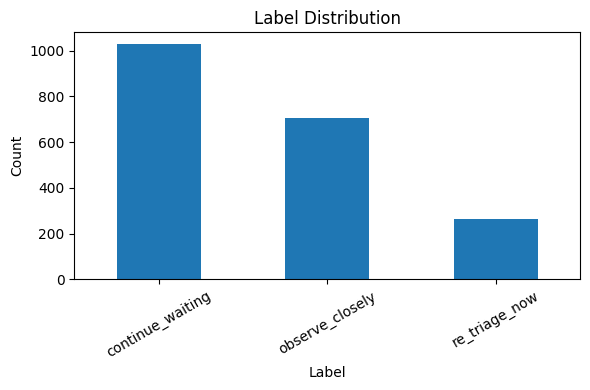

In [6]:
# ==========================================
# Step 4: EDA Figure 1-Label distribution
# ==========================================

plt.figure(figsize=(6, 4))
df["label"].value_counts().plot(kind="bar")
plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig(f"{report_dir}/eda_label_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

<Figure size 700x400 with 0 Axes>

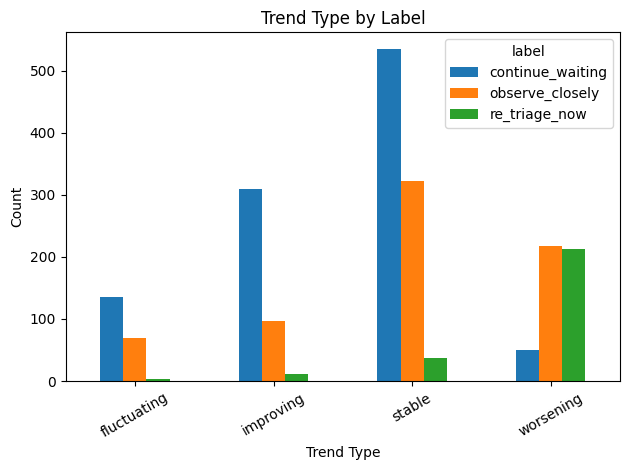

In [7]:
# ==========================================
# EDA Figure 2: Trend type by label
# ==========================================

trend_label = pd.crosstab(df["trend_type"], df["label"])

plt.figure(figsize=(7, 4))
trend_label.plot(kind="bar")
plt.title("Trend Type by Label")
plt.xlabel("Trend Type")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig(f"{report_dir}/eda_trend_type_by_label.png", dpi=150, bbox_inches="tight")
plt.show()

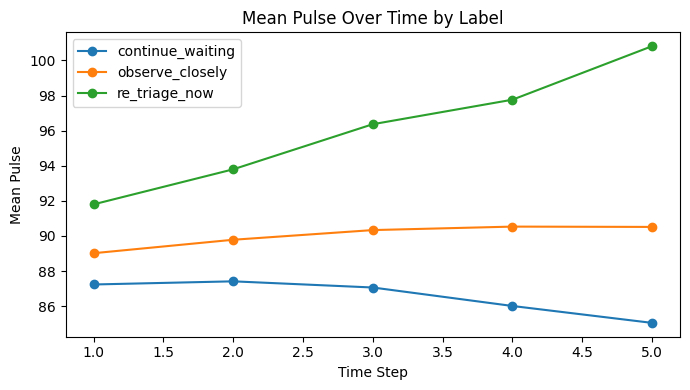

In [8]:
# ==========================================
# EDA Figure 3: Mean pulse over time by label
# ==========================================

pulse_cols = [f"pulse_t{i}" for i in range(1, 6)]

pulse_mean_by_label = df.groupby("label")[pulse_cols].mean()

plt.figure(figsize=(7, 4))

for label in pulse_mean_by_label.index:
    plt.plot(
        range(1, 6),
        pulse_mean_by_label.loc[label],
        marker="o",
        label=label
    )

plt.title("Mean Pulse Over Time by Label")
plt.xlabel("Time Step")
plt.ylabel("Mean Pulse")
plt.legend()
plt.tight_layout()

plt.savefig(f"{report_dir}/eda_mean_pulse_by_label.png", dpi=150, bbox_inches="tight")
plt.show()

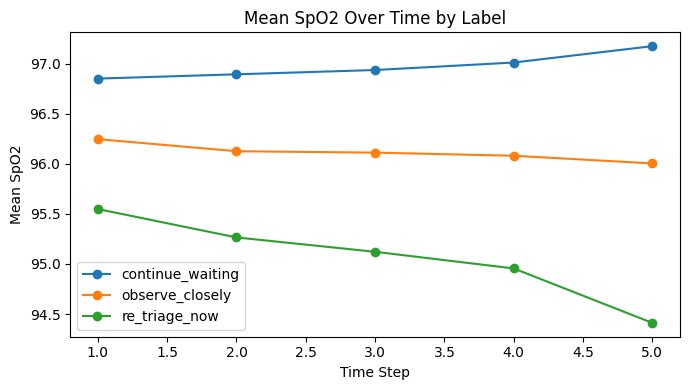

In [9]:
# ==========================================
# EDA Figure 4: Mean SpO2 over time by label
# ==========================================

spo2_cols = [f"spo2_t{i}" for i in range(1, 6)]

spo2_mean_by_label = df.groupby("label")[spo2_cols].mean()

plt.figure(figsize=(7, 4))

for label in spo2_mean_by_label.index:
    plt.plot(
        range(1, 6),
        spo2_mean_by_label.loc[label],
        marker="o",
        label=label
    )

plt.title("Mean SpO2 Over Time by Label")
plt.xlabel("Time Step")
plt.ylabel("Mean SpO2")
plt.legend()
plt.tight_layout()

plt.savefig(f"{report_dir}/eda_mean_spo2_by_label.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
# ==========================================
# Step 5: Prepare temporal sequence data
# ==========================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.utils import to_categorical

time_steps = 5

temporal_features = [
    "systolic_bp",
    "diastolic_bp",
    "pulse",
    "rr",
    "spo2",
    "temp"
]

# สร้าง X_seq shape = (n_samples, time_steps, n_features)
X_seq = []

for _, row in df.iterrows():
    patient_sequence = []
    for t in range(1, time_steps + 1):
        patient_sequence.append([
            row[f"systolic_bp_t{t}"],
            row[f"diastolic_bp_t{t}"],
            row[f"pulse_t{t}"],
            row[f"rr_t{t}"],
            row[f"spo2_t{t}"],
            row[f"temp_t{t}"]
        ])
    X_seq.append(patient_sequence)

X_seq = np.array(X_seq)

print("X_seq shape before scaling:", X_seq.shape)

X_seq shape before scaling: (2000, 5, 6)


In [11]:
# ==========================================
# Step 6: Scale temporal features
# ==========================================

n_samples, n_timesteps, n_features = X_seq.shape

# reshape เป็น 2D เพื่อ scale
X_seq_2d = X_seq.reshape(-1, n_features)

scaler = StandardScaler()
X_seq_2d_scaled = scaler.fit_transform(X_seq_2d)

# reshape กลับเป็น 3D
X_seq_scaled = X_seq_2d_scaled.reshape(n_samples, n_timesteps, n_features)

print("X_seq shape after scaling:", X_seq_scaled.shape)

X_seq shape after scaling: (2000, 5, 6)


In [12]:
# ==========================================
# Step 7: Encode labels
# ==========================================

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(df["label"])
y_cat = to_categorical(y_encoded)

print("Classes:", label_encoder.classes_)
print("y_cat shape:", y_cat.shape)

Classes: ['continue_waiting' 'observe_closely' 're_triage_now']
y_cat shape: (2000, 3)


In [13]:
# ==========================================
# Step 8: Split train / validation / test
# ==========================================

# แบ่ง train 70%, temp 30%
X_train, X_temp, y_train, y_temp = train_test_split(
    X_seq_scaled,
    y_cat,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded
)

# ต้องใช้ label แบบตัวเลขสำหรับ stratify รอบสอง
y_temp_label = np.argmax(y_temp, axis=1)

# แบ่ง temp เป็น validation 15%, test 15%
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp_label
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (1400, 5, 6) (1400, 3)
Validation: (300, 5, 6) (300, 3)
Test: (300, 5, 6) (300, 3)


In [14]:
# ==========================================
# Step 9: Function to save training plots
# ==========================================

def save_training_plots(history, model_id, title_prefix):
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]

    epochs = range(1, len(acc) + 1)

    # Accuracy plot
    plt.figure(figsize=(6, 4))
    plt.plot(epochs, acc, "bo", label="Training accuracy")
    plt.plot(epochs, val_acc, "b", label="Validation accuracy")
    plt.title(f"{title_prefix}: Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()

    acc_path = f"{report_dir}/{model_id}_accuracy.png"
    plt.savefig(acc_path, dpi=150, bbox_inches="tight")
    plt.show()

    # Loss plot
    plt.figure(figsize=(6, 4))
    plt.plot(epochs, loss, "bo", label="Training loss")
    plt.plot(epochs, val_loss, "b", label="Validation loss")
    plt.title(f"{title_prefix}: Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()

    loss_path = f"{report_dir}/{model_id}_loss.png"
    plt.savefig(loss_path, dpi=150, bbox_inches="tight")
    plt.show()

    return acc_path, loss_path

In [15]:
# ==========================================
# Step 10: Result table container
# ==========================================

experiment_results = []

In [16]:
# ==========================================
# Step 11: Experiment 1 - 1D-CNN
# ==========================================

from tensorflow import keras
from tensorflow.keras import layers

num_classes = y_cat.shape[1]

cnn_model = keras.Sequential([
    layers.Input(shape=(time_steps, n_features)),

    layers.Conv1D(filters=32, kernel_size=2, activation="relu"),
    layers.MaxPooling1D(pool_size=2),

    layers.Conv1D(filters=64, kernel_size=2, activation="relu"),

    layers.GlobalAveragePooling1D(),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(num_classes, activation="softmax")
])

cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 4, 32)          │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 2, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 1, 64)          │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,931 (34.89 KB)

 Trainable params: 8,931 (34.89 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# ==========================================
# Step 12: Train 1D-CNN
# ==========================================

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="exp1_1dcnn_retriage.keras",
        save_best_only=True,
        monitor="val_loss"
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True
    )
]

history_cnn = cnn_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=callbacks
)

Epoch 1/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5279 - loss: 0.9776 - val_accuracy: 0.5667 - val_loss: 0.9012
Epoch 2/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5714 - loss: 0.8825 - val_accuracy: 0.5667 - val_loss: 0.8560
Epoch 3/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5971 - loss: 0.8473 - val_accuracy: 0.5700 - val_loss: 0.8380
Epoch 4/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5871 - loss: 0.8222 - val_accuracy: 0.6033 - val_loss: 0.8093
Epoch 5/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6264 - loss: 0.7881 - val_accuracy: 0.5900 - val_loss: 0.7955
Epoch 6/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6443 - loss: 0.7656 - val_accuracy: 0.6133 - val_loss: 0.7685
Epoch 7/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6629 - loss: 0.7412 - val_accuracy: 0.6200 - val_loss: 0.7484
Epoch 8/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6493 - loss: 0.7309 - val_accuracy: 0.6433 - val_loss

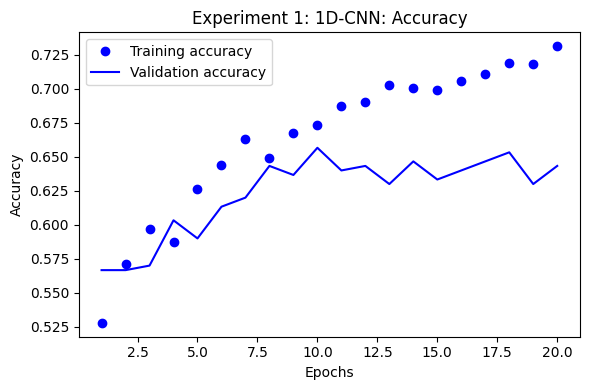

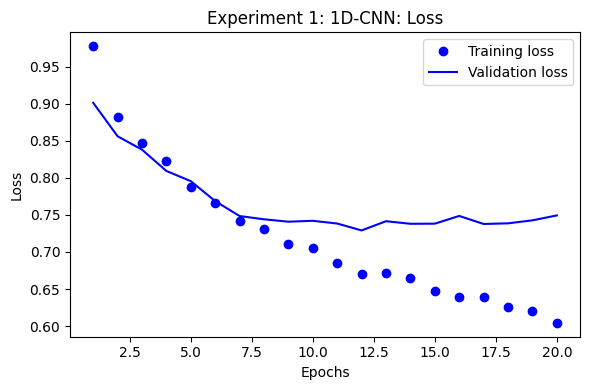

1D-CNN Test Accuracy: 0.657
1D-CNN Test Loss: 0.773


In [18]:
# ==========================================
# Step 13: Plot, save, evaluate 1D-CNN
# ==========================================

save_training_plots(
    history=history_cnn,
    model_id="exp1_1dcnn_retriage",
    title_prefix="Experiment 1: 1D-CNN"
)

best_cnn_model = keras.models.load_model("exp1_1dcnn_retriage.keras")

test_loss, test_acc = best_cnn_model.evaluate(X_test, y_test, verbose=0)

experiment_results.append({
    "Model ID": "Exp 1",
    "รายละเอียดการปรับปรุง (Model Changes)": "1D-CNN สำหรับ repeated vital signs 5 time steps",
    "Training Acc.": max(history_cnn.history["accuracy"]),
    "Validation Acc.": max(history_cnn.history["val_accuracy"]),
    "Test Accuracy": test_acc,
    "Test Loss": test_loss,
    "หมายเหตุ": "ใช้ Conv1D เพื่อจับ pattern การเปลี่ยนแปลงของสัญญาณชีพตามเวลา"
})

print(f"1D-CNN Test Accuracy: {test_acc:.3f}")
print(f"1D-CNN Test Loss: {test_loss:.3f}")

In [19]:
# ==========================================
# Step 14: Experiment 2 - GRU
# ==========================================

gru_model = keras.Sequential([
    layers.Input(shape=(time_steps, n_features)),

    layers.GRU(64, return_sequences=False),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(num_classes, activation="softmax")
])

gru_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

gru_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        13,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,179 (71.01 KB)

 Trainable params: 18,179 (71.01 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# ==========================================
# Step 15: Train GRU
# ==========================================

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="exp2_gru_retriage.keras",
        save_best_only=True,
        monitor="val_loss"
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True
    )
]

history_gru = gru_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=callbacks
)

Epoch 1/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.5364 - loss: 0.9386 - val_accuracy: 0.6133 - val_loss: 0.8428
Epoch 2/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6050 - loss: 0.8428 - val_accuracy: 0.6233 - val_loss: 0.8061
Epoch 3/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6071 - loss: 0.8226 - val_accuracy: 0.6100 - val_loss: 0.7903
Epoch 4/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6150 - loss: 0.7932 - val_accuracy: 0.6467 - val_loss: 0.7695
Epoch 5/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6257 - loss: 0.7824 - val_accuracy: 0.6567 - val_loss: 0.7532
Epoch 6/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6393 - loss: 0.7528 - val_accuracy: 0.6700 - val_loss: 0.7350
Epoch 7/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6486 - loss: 0.7359 - val_accuracy: 0.6700 - val_loss: 0.7148
Epoch 8/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6471 - loss: 0.7423 - val_accuracy: 0.6767 - val_loss

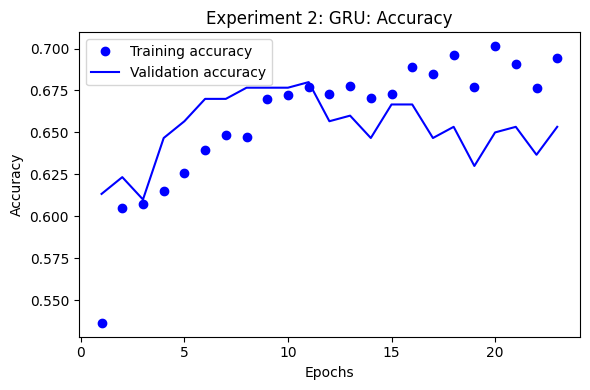

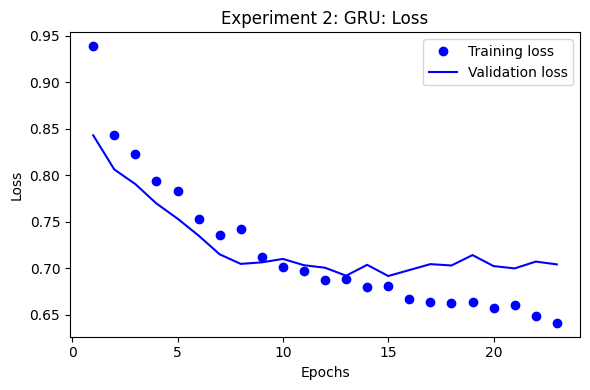

GRU Test Accuracy: 0.673
GRU Test Loss: 0.728


In [21]:
# ==========================================
# Step 16: Plot, save, evaluate GRU
# ==========================================

save_training_plots(
    history=history_gru,
    model_id="exp2_gru_retriage",
    title_prefix="Experiment 2: GRU"
)

best_gru_model = keras.models.load_model("exp2_gru_retriage.keras")

test_loss, test_acc = best_gru_model.evaluate(X_test, y_test, verbose=0)

experiment_results.append({
    "Model ID": "Exp 2",
    "รายละเอียดการปรับปรุง (Model Changes)": "GRU สำหรับเรียนรู้ลำดับการเปลี่ยนแปลงของสัญญาณชีพ",
    "Training Acc.": max(history_gru.history["accuracy"]),
    "Validation Acc.": max(history_gru.history["val_accuracy"]),
    "Test Accuracy": test_acc,
    "Test Loss": test_loss,
    "หมายเหตุ": "ใช้ recurrent layer เพื่อเรียนรู้ temporal dependency ของ vital signs"
})

print(f"GRU Test Accuracy: {test_acc:.3f}")
print(f"GRU Test Loss: {test_loss:.3f}")

In [22]:
# ==========================================
# Step 17: Create result summary table
# ==========================================

results_df = pd.DataFrame(experiment_results)

results_df["Training Acc."] = results_df["Training Acc."].round(3)
results_df["Validation Acc."] = results_df["Validation Acc."].round(3)
results_df["Test Accuracy"] = results_df["Test Accuracy"].round(3)
results_df["Test Loss"] = results_df["Test Loss"].round(3)

results_df

,Model ID,รายละเอียดการปรับปรุง (Model Changes),Training Acc.,Validation Acc.,Test Accuracy,Test Loss,หมายเหตุ
0,Exp 1,1D-CNN สำหรับ repeated vital signs 5 time steps,0.731,0.657,0.657,0.773,ใช้ Conv1D เพื่อจับ pattern การเปลี่ยนแปลงของส...
1,Exp 2,GRU สำหรับเรียนรู้ลำดับการเปลี่ยนแปลงของสัญญาณชีพ,0.701,0.680,0.673,0.728,ใช้ recurrent layer เพื่อเรียนรู้ temporal dep...


In [24]:
# ==========================================
# Step 18: Save result table as CSV
# ==========================================

csv_filename = "MiniProject_6810038288_Samart.csv"

results_df.to_csv(
    csv_filename,
    index=False,
    encoding="utf-8-sig"
)

print(f"Saved file: {csv_filename}")

Saved file: MiniProject_6810038288_Samart.csv


In [25]:
from google.colab import files

files.download("MiniProject_6810038288_Samart.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ==========================================
# Step 19: Display saved figures with captions
# ==========================================

from IPython.display import Image, display, Markdown

display(Image(filename="/content/report_figures_retriage/eda_label_distribution.png"))
display(Markdown("**รูปภาพที่ 1 การกระจายของ Label ในชุดข้อมูล**"))

display(Image(filename="/content/report_figures_retriage/eda_trend_type_by_label.png"))
display(Markdown("**รูปภาพที่ 2 ความสัมพันธ์ระหว่าง Trend Type และ Label**"))

display(Image(filename="/content/report_figures_retriage/eda_mean_pulse_by_label.png"))
display(Markdown("**รูปภาพที่ 3 ค่าเฉลี่ย Pulse ตาม Time Step แยกตาม Label**"))

display(Image(filename="/content/report_figures_retriage/eda_mean_spo2_by_label.png"))
display(Markdown("**รูปภาพที่ 4 ค่าเฉลี่ย SpO2 ตาม Time Step แยกตาม Label**"))

display(Image(filename="/content/report_figures_retriage/exp1_1dcnn_retriage_accuracy.png"))
display(Markdown("**รูปภาพที่ 5 กราฟ Accuracy ของ Experiment 1: 1D-CNN**"))

display(Image(filename="/content/report_figures_retriage/exp1_1dcnn_retriage_loss.png"))
display(Markdown("**รูปภาพที่ 6 กราฟ Loss ของ Experiment 1: 1D-CNN**"))

display(Image(filename="/content/report_figures_retriage/exp2_gru_retriage_accuracy.png"))
display(Markdown("**รูปภาพที่ 7 กราฟ Accuracy ของ Experiment 2: GRU**"))

display(Image(filename="/content/report_figures_retriage/exp2_gru_retriage_loss.png"))
display(Markdown("**รูปภาพที่ 8 กราฟ Loss ของ Experiment 2: GRU**"))

# การวิเคราะห์ผล

# 1. การวิเคราะห์ผลการทดลอง

การทดลองนี้ใช้ชุดข้อมูล mockup จำนวน 2,000 ราย สำหรับพัฒนาโมเดล Deep Learning เพื่อช่วยทำนายคำแนะนำในการดูแลผู้ป่วยระหว่างรอในห้องฉุกเฉิน โดยข้อมูลมีลักษณะเป็น temporal data หรือข้อมูลตามลำดับเวลา ผู้ป่วย 1 รายมีการบันทึกสัญญาณชีพซ้ำ 5 time steps

ข้อมูลที่ใช้ในโมเดลประกอบด้วย systolic blood pressure, diastolic blood pressure, pulse, respiratory rate, oxygen saturation และ temperature โดยมี label แบ่งออกเป็น 3 กลุ่ม ได้แก่ continue_waiting, observe_closely และ re_triage_now

In [27]:
# แสดงตารางเปรียบเทียบผลการทดลอง
results_df

,Model ID,รายละเอียดการปรับปรุง (Model Changes),Training Acc.,Validation Acc.,Test Accuracy,Test Loss,หมายเหตุ
0,Exp 1,1D-CNN สำหรับ repeated vital signs 5 time steps,0.731,0.657,0.657,0.773,ใช้ Conv1D เพื่อจับ pattern การเปลี่ยนแปลงของส...
1,Exp 2,GRU สำหรับเรียนรู้ลำดับการเปลี่ยนแปลงของสัญญาณชีพ,0.701,0.680,0.673,0.728,ใช้ recurrent layer เพื่อเรียนรู้ temporal dep...


## 2 ภาพรวมของข้อมูล

จากการสำรวจข้อมูลเบื้องต้น พบว่าข้อมูลมีการกระจายของ label ทั้ง 3 กลุ่ม ได้แก่ continue_waiting, observe_closely และ re_triage_now ซึ่งใช้เป็นผลลัพธ์สำหรับการฝึกโมเดล classification

รายละเอียดการกระจายของ label แสดงดังรูปภาพที่ 1

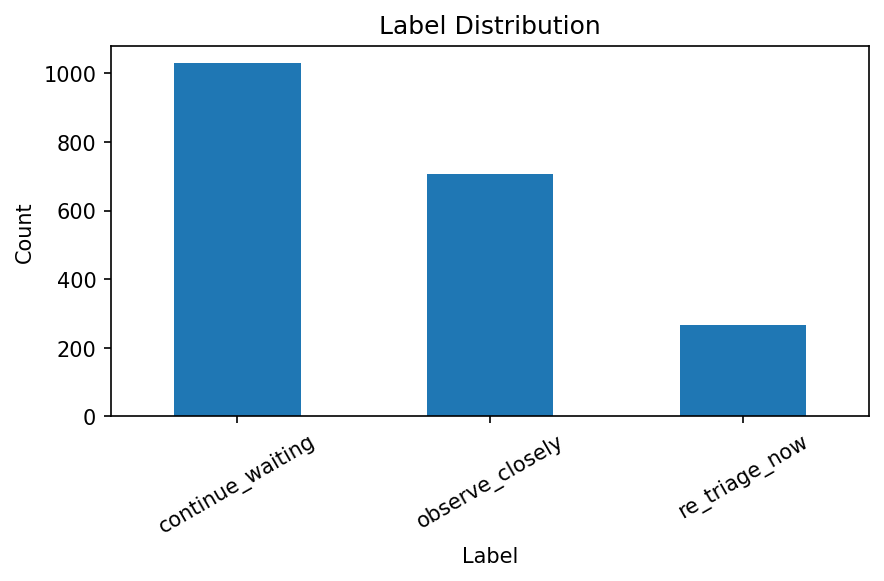

**รูปภาพที่ 1 การกระจายของ Label ในชุดข้อมูล**

In [29]:
from IPython.display import Image, display, Markdown

display(Image(filename="/content/report_figures_retriage/eda_label_distribution.png"))
display(Markdown("**รูปภาพที่ 1 การกระจายของ Label ในชุดข้อมูล**"))

จากรูปภาพที่ 1 สามารถใช้พิจารณาความสมดุลของข้อมูลในแต่ละ class ได้ หากข้อมูลแต่ละ class มีจำนวนต่างกันมาก อาจทำให้โมเดลเรียนรู้ class ที่มีจำนวนมากได้ดีกว่า class ที่มีจำนวนน้อย ดังนั้นการดู class distribution จึงมีความสำคัญก่อนนำข้อมูลไปสร้างโมเดล

## 3 ความสัมพันธ์ระหว่าง Trend Type และ Label

ข้อมูลชุดนี้มีตัวแปร trend_type ที่แสดงลักษณะการเปลี่ยนแปลงของสัญญาณชีพระหว่างรอ เช่น stable, improving, worsening และ fluctuating ตัวแปรนี้ช่วยสะท้อนแนวโน้มของผู้ป่วยในระหว่างการรอประเมินซ้ำ

รายละเอียดความสัมพันธ์ระหว่าง trend_type และ label แสดงดังรูปภาพที่ 2

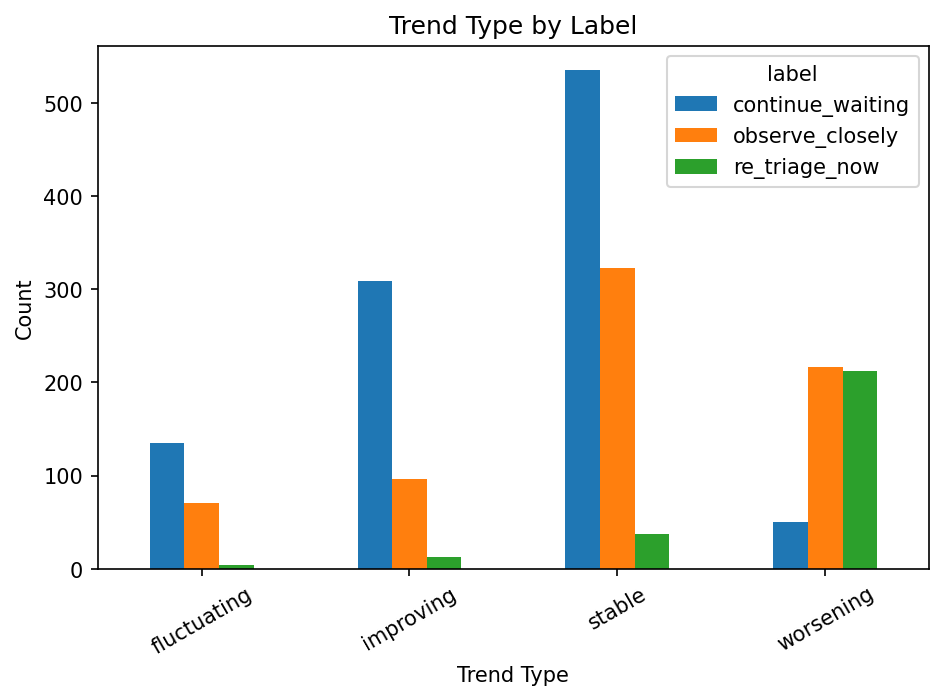

**รูปภาพที่ 2 ความสัมพันธ์ระหว่าง Trend Type และ Label**

In [30]:
display(Image(filename="/content/report_figures_retriage/eda_trend_type_by_label.png"))
display(Markdown("**รูปภาพที่ 2 ความสัมพันธ์ระหว่าง Trend Type และ Label**"))

จากรูปภาพที่ 2 หากพบว่ากลุ่ม worsening มีจำนวนผู้ป่วยในกลุ่ม observe_closely หรือ re_triage_now มากขึ้น แสดงว่าตัวแปร trend_type มีความสัมพันธ์กับความเสี่ยงของผู้ป่วย และอาจเป็น feature สำคัญที่ช่วยให้โมเดลเรียนรู้การเปลี่ยนแปลงของอาการได้ดีขึ้น

## 3 การเปลี่ยนแปลงของ Pulse ตามเวลา

ค่า pulse เป็นหนึ่งในสัญญาณชีพที่สำคัญในการติดตามอาการของผู้ป่วยระหว่างรอ หาก pulse มีแนวโน้มเพิ่มขึ้นอย่างต่อเนื่อง อาจสะท้อนถึงความเครียดของร่างกาย ไข้ ภาวะขาดน้ำ หรือภาวะที่ต้องเฝ้าระวังมากขึ้น

รายละเอียดค่าเฉลี่ย pulse ตาม time step แยกตาม label แสดงดังรูปภาพที่ 3

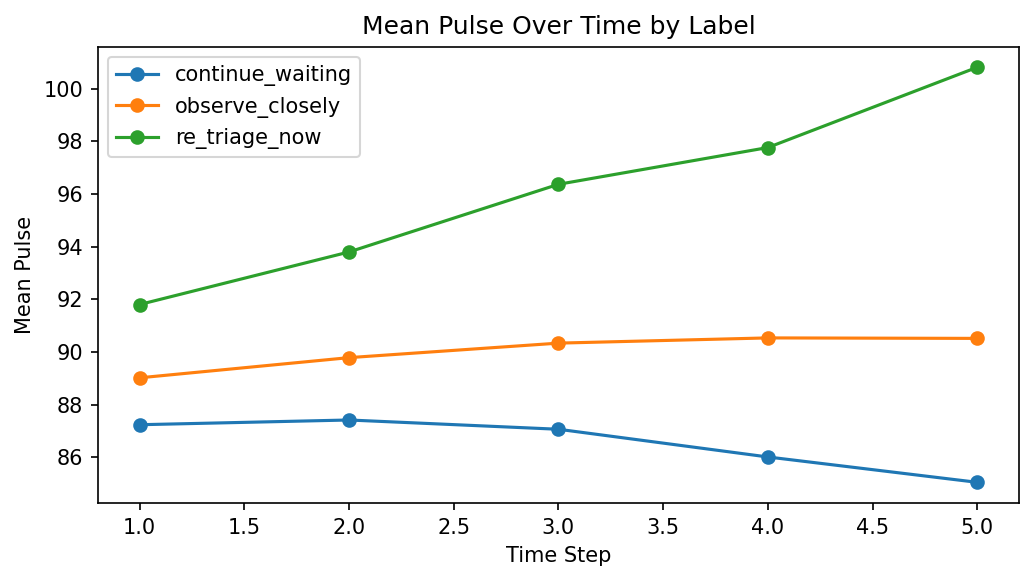

**รูปภาพที่ 3 ค่าเฉลี่ย Pulse ตาม Time Step แยกตาม Label**

In [31]:
display(Image(filename="/content/report_figures_retriage/eda_mean_pulse_by_label.png"))
display(Markdown("**รูปภาพที่ 3 ค่าเฉลี่ย Pulse ตาม Time Step แยกตาม Label**"))

จากรูปภาพที่ 3 หากกลุ่ม re_triage_now หรือ observe_closely มีค่า pulse สูงกว่ากลุ่ม continue_waiting หรือมีแนวโน้มเพิ่มขึ้นตาม time step แสดงว่า pulse อาจเป็นตัวแปรสำคัญในการช่วยทำนายความจำเป็นในการประเมินซ้ำของผู้ป่วย

## 4 การเปลี่ยนแปลงของ SpO2 ตามเวลา

ค่า oxygen saturation หรือ SpO2 เป็นตัวแปรสำคัญในการประเมินภาวะระบบหายใจ หาก SpO2 ลดลงระหว่างรอ อาจสะท้อนว่าผู้ป่วยมีความเสี่ยงเพิ่มขึ้นและควรได้รับการเฝ้าระวังหรือประเมินซ้ำ

รายละเอียดค่าเฉลี่ย SpO2 ตาม time step แยกตาม label แสดงดังรูปภาพที่ 4

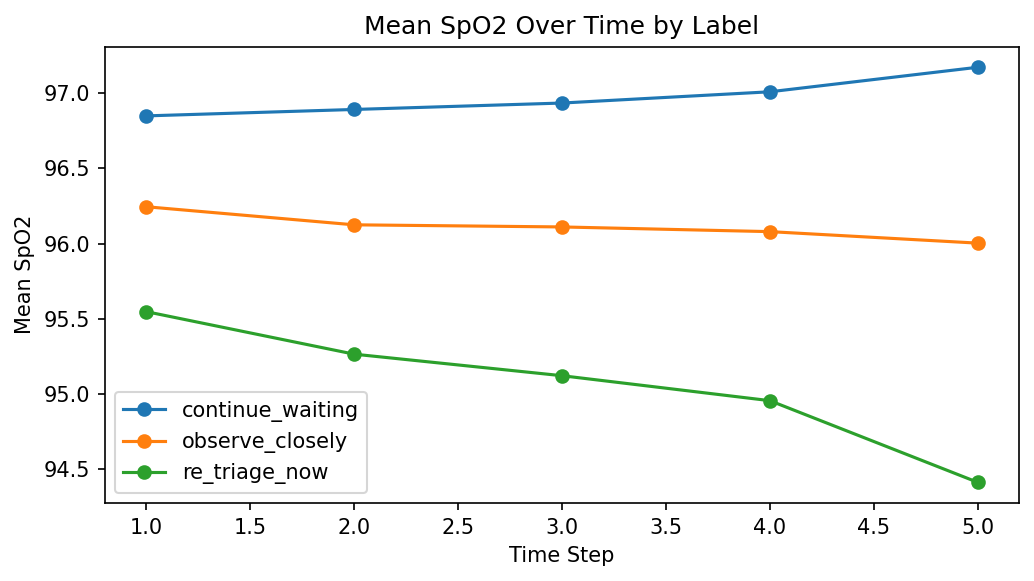

**รูปภาพที่ 4 ค่าเฉลี่ย SpO2 ตาม Time Step แยกตาม Label**

In [32]:
display(Image(filename="/content/report_figures_retriage/eda_mean_spo2_by_label.png"))
display(Markdown("**รูปภาพที่ 4 ค่าเฉลี่ย SpO2 ตาม Time Step แยกตาม Label**"))

จากรูปภาพที่ 4 หากกลุ่ม re_triage_now มีค่า SpO2 ต่ำกว่ากลุ่มอื่น หรือมีแนวโน้มลดลงตาม time step แสดงว่า SpO2 เป็นสัญญาณชีพที่มีความสำคัญต่อการประเมินความเสี่ยง และเหมาะสมที่จะนำมาใช้ในโมเดล temporal deep learning

## 5 Experiment 1: 1D-CNN

โมเดล 1D-CNN ถูกใช้เพื่อเรียนรู้ pattern ระยะสั้นของสัญญาณชีพที่เปลี่ยนแปลงตามเวลา โดย Conv1D สามารถจับความสัมพันธ์ของข้อมูลในช่วง time steps ต่อเนื่องกัน เช่น การเพิ่มขึ้นของ pulse หรือการลดลงของ SpO2 ในช่วงเวลาสั้น ๆ

โมเดลนี้เหมาะกับข้อมูลที่ต้องการตรวจจับ local temporal pattern หรือรูปแบบการเปลี่ยนแปลงเฉพาะช่วงเวลา

รายละเอียดกราฟ Accuracy ของโมเดล 1D-CNN แสดงดังรูปภาพที่ 5

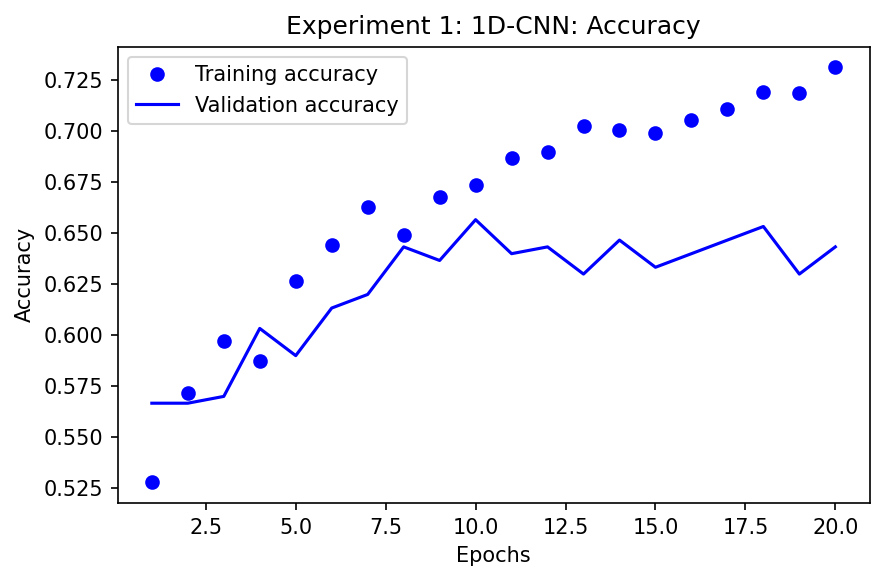

**รูปภาพที่ 5 กราฟ Accuracy ของ Experiment 1: 1D-CNN**

In [33]:
display(Image(filename="/content/report_figures_retriage/exp1_1dcnn_retriage_accuracy.png"))
display(Markdown("**รูปภาพที่ 5 กราฟ Accuracy ของ Experiment 1: 1D-CNN**"))

จากรูปภาพที่ 5 หาก Training Accuracy และ Validation Accuracy เพิ่มขึ้นไปในทิศทางเดียวกัน แสดงว่าโมเดลสามารถเรียนรู้ pattern จากข้อมูล training และสามารถ generalize ไปยัง validation set ได้ดี แต่ถ้า Training Accuracy สูงขึ้นมากในขณะที่ Validation Accuracy คงที่หรือลดลง อาจเป็นสัญญาณของ overfitting

รายละเอียดกราฟ Loss ของโมเดล 1D-CNN แสดงดังรูปภาพที่ 6

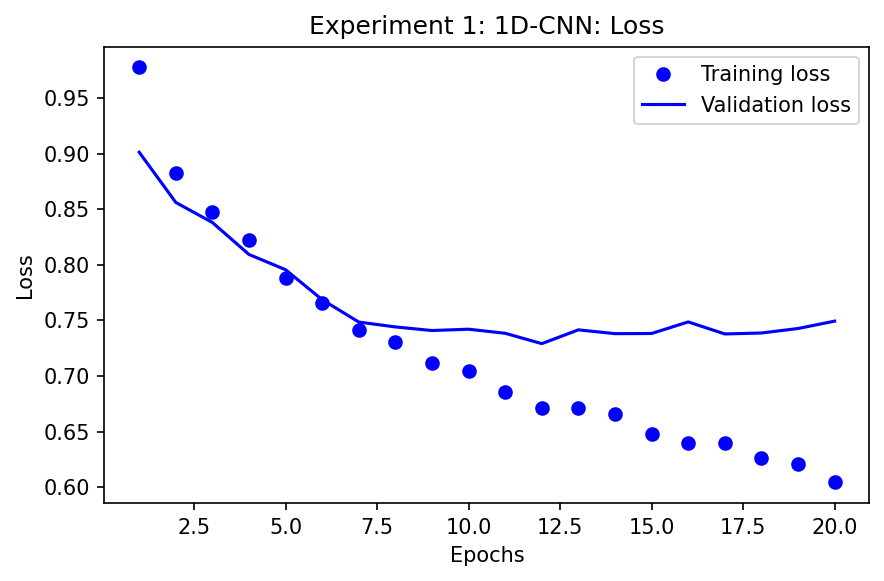

**รูปภาพที่ 6 กราฟ Loss ของ Experiment 1: 1D-CNN**

In [34]:
display(Image(filename="/content/report_figures_retriage/exp1_1dcnn_retriage_loss.png"))
display(Markdown("**รูปภาพที่ 6 กราฟ Loss ของ Experiment 1: 1D-CNN**"))

จากรูปภาพที่ 6 หาก Training Loss และ Validation Loss ลดลงพร้อมกัน แสดงว่าโมเดลเรียนรู้ได้ดีและมีแนวโน้ม generalize ได้ดี แต่ถ้า Validation Loss เริ่มสูงขึ้นในขณะที่ Training Loss ลดลงต่อเนื่อง อาจสะท้อนว่าโมเดลเริ่มจดจำข้อมูล training set มากเกินไป

## 6 Experiment 2: GRU

โมเดล GRU ถูกใช้เพื่อเรียนรู้ลำดับการเปลี่ยนแปลงของสัญญาณชีพตามเวลา GRU เป็น recurrent neural network ชนิดหนึ่งที่สามารถจดจำ pattern ก่อนหน้าและนำมาใช้ในการทำนายผลลัพธ์ในลำดับถัดไป

โมเดลนี้เหมาะกับโจทย์ re-triage prediction เพราะการเปลี่ยนแปลงของสัญญาณชีพไม่ได้ขึ้นอยู่กับค่า ณ จุดเวลาเดียวเท่านั้น แต่ขึ้นอยู่กับแนวโน้มระหว่างช่วงเวลารอด้วย

รายละเอียดกราฟ Accuracy ของโมเดล GRU แสดงดังรูปภาพที่ 7

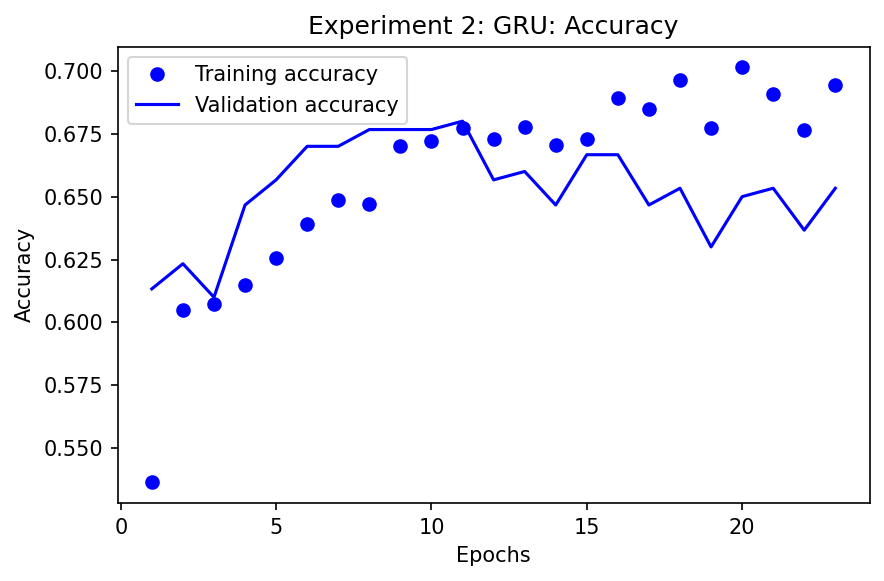

**รูปภาพที่ 7 กราฟ Accuracy ของ Experiment 2: GRU**

In [35]:
display(Image(filename="/content/report_figures_retriage/exp2_gru_retriage_accuracy.png"))
display(Markdown("**รูปภาพที่ 7 กราฟ Accuracy ของ Experiment 2: GRU**"))

จากรูปภาพที่ 7 สามารถพิจารณาได้ว่า GRU เรียนรู้ temporal dependency ได้ดีเพียงใด หาก Validation Accuracy สูงกว่า 1D-CNN หรือมีความเสถียรมากกว่า อาจแสดงว่า GRU เหมาะกับข้อมูลสัญญาณชีพที่มีลำดับเวลามากกว่า

รายละเอียดกราฟ Loss ของโมเดล GRU แสดงดังรูปภาพที่ 8

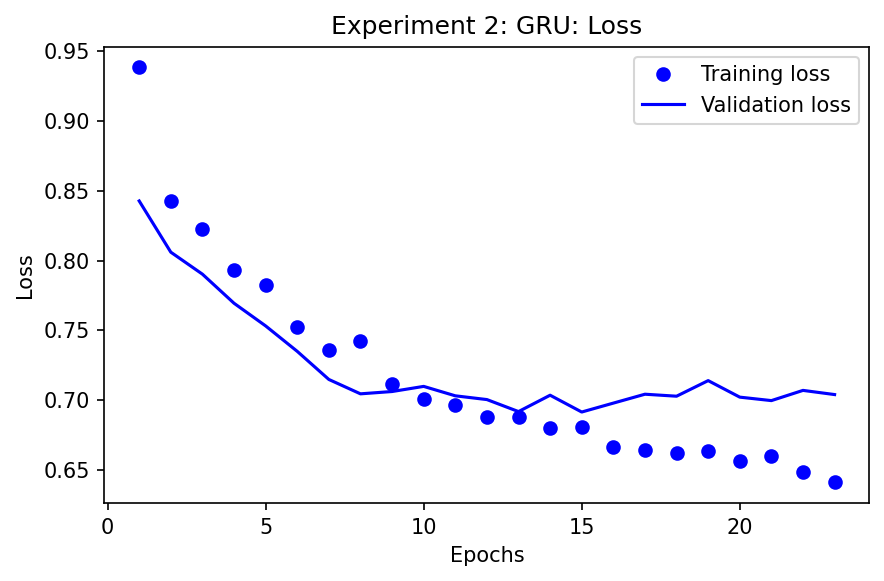

**รูปภาพที่ 8 กราฟ Loss ของ Experiment 2: GRU**

In [36]:
display(Image(filename="/content/report_figures_retriage/exp2_gru_retriage_loss.png"))
display(Markdown("**รูปภาพที่ 8 กราฟ Loss ของ Experiment 2: GRU**"))

จากรูปภาพที่ 8 หาก Validation Loss ของ GRU ต่ำกว่า 1D-CNN แสดงว่า GRU สามารถลดความผิดพลาดบนข้อมูล validation ได้ดีกว่า อย่างไรก็ตาม หาก Loss แกว่งมาก อาจต้องปรับ learning rate, batch size หรือจำนวน hidden units เพิ่มเติม

In [37]:
# แสดงตารางเปรียบเทียบผลการทดลอง
results_df

,Model ID,รายละเอียดการปรับปรุง (Model Changes),Training Acc.,Validation Acc.,Test Accuracy,Test Loss,หมายเหตุ
0,Exp 1,1D-CNN สำหรับ repeated vital signs 5 time steps,0.731,0.657,0.657,0.773,ใช้ Conv1D เพื่อจับ pattern การเปลี่ยนแปลงของส...
1,Exp 2,GRU สำหรับเรียนรู้ลำดับการเปลี่ยนแปลงของสัญญาณชีพ,0.701,0.680,0.673,0.728,ใช้ recurrent layer เพื่อเรียนรู้ temporal dep...


# สรุปผลการทดลอง

## 1 Overfitting Analysis

จากผลการทดลองพบว่าโมเดล 1D-CNN มี Training Accuracy เท่ากับ 0.731 และ Validation Accuracy เท่ากับ 0.657 โดยมีช่องว่างประมาณ 0.074 แสดงว่าโมเดลมีแนวโน้มเกิด overfitting ในระดับหนึ่ง เนื่องจากเรียนรู้ข้อมูล training set ได้ดีกว่า validation set ค่อนข้างชัดเจน

ในขณะที่โมเดล GRU มี Training Accuracy เท่ากับ 0.701 และ Validation Accuracy เท่ากับ 0.680 โดยมีช่องว่างประมาณ 0.021 ซึ่งน้อยกว่า 1D-CNN มาก แสดงว่า GRU มีความสามารถในการ generalize ไปยังข้อมูล validation ได้ดีกว่า และมีแนวโน้ม overfitting น้อยกว่า

เมื่อพิจารณาร่วมกับค่า Test Loss พบว่า 1D-CNN มี Test Loss เท่ากับ 0.773 ส่วน GRU มี Test Loss เท่ากับ 0.728 ซึ่งต่ำกว่า แสดงว่า GRU มีความผิดพลาดบน test set น้อยกว่า ดังนั้นในการทดลองนี้ GRU สามารถลดปัญหา overfitting และให้ผลลัพธ์ที่เสถียรกว่า 1D-CNN

## 2 Comparison between 1D-CNN and GRU

โมเดล 1D-CNN ให้ Test Accuracy เท่ากับ 0.657 ในขณะที่โมเดล GRU ให้ Test Accuracy เท่ากับ 0.673 ซึ่งสูงกว่าเล็กน้อย แสดงว่า GRU สามารถทำนายข้อมูลใหม่ได้ดีกว่า 1D-CNN ในการทดลองนี้

ผลลัพธ์นี้สอดคล้องกับลักษณะของโจทย์ เนื่องจากข้อมูลเป็น repeated vital signs จำนวน 5 time steps ซึ่งมีลำดับของการเปลี่ยนแปลงตามเวลา โมเดล GRU ซึ่งออกแบบมาเพื่อเรียนรู้ temporal dependency จึงสามารถใช้ข้อมูลจาก time steps ก่อนหน้าเพื่อช่วยในการจำแนก label ได้ดีกว่า

ส่วน 1D-CNN สามารถจับ local temporal pattern ได้ เช่น การเปลี่ยนแปลงของ vital signs ในช่วงเวลาสั้น ๆ แต่จากผลการทดลองยังไม่สามารถทำงานได้ดีกว่า GRU อาจเนื่องจากข้อมูลมีลักษณะเป็นลำดับเวลา และจำนวน time steps มีเพียง 5 จุด ทำให้การเรียนรู้ dependency ตามลำดับมีความสำคัญมากกว่าการจับ pattern เฉพาะช่วงสั้น

## 3 Model Selection

เมื่อพิจารณาจาก Test Accuracy และ Test Loss ร่วมกัน โมเดลที่เหมาะสมกว่าในการทดลองนี้คือ GRU เนื่องจากมี Test Accuracy สูงกว่า 1D-CNN โดย GRU ได้ 0.673 ขณะที่ 1D-CNN ได้ 0.657 และ GRU ยังมี Test Loss ต่ำกว่า โดยได้ 0.728 เทียบกับ 1D-CNN ที่ได้ 0.773

นอกจากนี้ GRU ยังมีช่องว่างระหว่าง Training Accuracy และ Validation Accuracy น้อยกว่า แสดงว่าโมเดลมีแนวโน้ม generalize ได้ดีกว่าและเกิด overfitting น้อยกว่า 1D-CNN

ดังนั้น หากเลือกโมเดลสำหรับนำไปพัฒนาต่อในระบบ AI for Re-Triage Prediction ควรเลือก GRU เป็นโมเดลหลัก เนื่องจากเหมาะกับข้อมูลสัญญาณชีพที่มีลำดับเวลา และให้ผลลัพธ์โดยรวมดีที่สุดในการทดลองนี้